In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
train_dataset = pd.read_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/train_dataset_v6_lane_vehicle.csv"
)

test_dataset = pd.read_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/test_dataset_v6_lane_vehicle.csv"
)

print(train_dataset.shape)
print(test_dataset.shape)

(242965, 198)
(66060, 198)


In [5]:
behavior_map = {
    "NORMAL1": "NORMAL",
    "NORMAL2": "NORMAL"
}

train_dataset["behavior"] = (
    train_dataset["behavior"]
    .replace(behavior_map)
)

test_dataset["behavior"] = (
    test_dataset["behavior"]
    .replace(behavior_map)
)

print(train_dataset["behavior"].value_counts())

print()

print(test_dataset["behavior"].value_counts())

behavior
NORMAL        116203
AGGRESSIVE     63761
DROWSY         63001
Name: count, dtype: int64

behavior
DROWSY        36143
AGGRESSIVE    15257
NORMAL        14660
Name: count, dtype: int64


In [6]:
target_column = "behavior"

feature_columns = [

    col

    for col in train_dataset.columns

    if col not in [

        "behavior",
        "driver",
        "trip",
        "road_type"

    ]

]

X_train = train_dataset[feature_columns]
X_test = test_dataset[feature_columns]

y_train = train_dataset[target_column]
y_test = test_dataset[target_column]

print(X_train.shape)
print(X_test.shape)

(242965, 194)
(66060, 194)


In [7]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)

y_test = label_encoder.transform(y_test)

print(label_encoder.classes_)

['AGGRESSIVE' 'DROWSY' 'NORMAL']


In [8]:
xgb_model = XGBClassifier(

    random_state=42,

    objective="multi:softmax",

    num_class=3,

    eval_metric="mlogloss"

)

In [9]:
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [10]:
xgb_pred = xgb_model.predict(
    X_test
)

xgb_pred[:10]

array([0, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [11]:
accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6800


In [12]:
print(

    classification_report(

        y_test,

        xgb_pred,

        target_names=label_encoder.classes_

    )

)

              precision    recall  f1-score   support

  AGGRESSIVE       0.86      0.82      0.84     15257
      DROWSY       0.89      0.56      0.68     36143
      NORMAL       0.42      0.84      0.56     14660

    accuracy                           0.68     66060
   macro avg       0.73      0.74      0.70     66060
weighted avg       0.78      0.68      0.69     66060



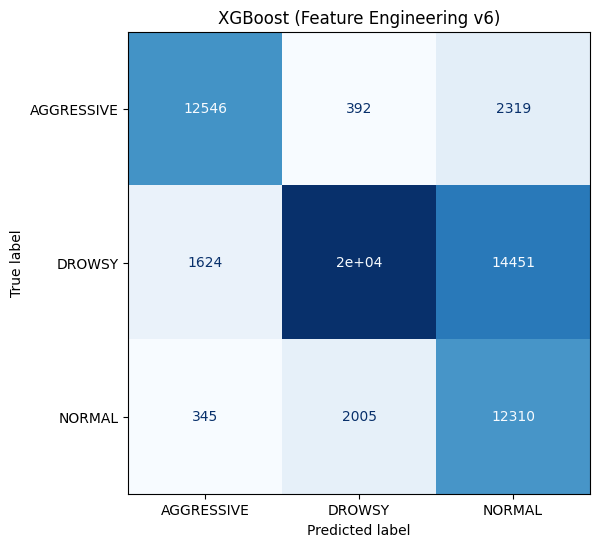

In [13]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("XGBoost (Feature Engineering v6)")

plt.show()

In [14]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": xgb_model.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

importance.head(30)

,Feature,Importance
110,steering_alignment_variance,0.111961
182,ttc_trend_variance,0.096070
94,lane_offset_q75,0.046578
150,relative_speed_rms,0.038577
166,closing_speed_q75,0.029769
28,speed_max,0.026069
9,acc_resultant_q25,0.022036
95,lane_offset_iqr,0.019873
2,acc_resultant_variance,0.017082
5,acc_resultant_median,0.016737


# XGBoost Tuning v1

In [15]:
xgb_model_v1 = XGBClassifier(

    random_state=42,

    objective="multi:softmax",
    num_class=3,

    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,

    subsample=0.8,
    colsample_bytree=0.8,

    eval_metric="mlogloss"

)

In [16]:
xgb_model_v1.fit(
    X_train,
    y_train
)

print("XGBoost Tuning v1 trained successfully!")

XGBoost Tuning v1 trained successfully!


In [17]:
xgb_pred_v1 = xgb_model_v1.predict(
    X_test
)

xgb_pred_v1[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [18]:
accuracy = accuracy_score(
    y_test,
    xgb_pred_v1
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6697


In [19]:
print(
    classification_report(
        y_test,
        xgb_pred_v1,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  AGGRESSIVE       0.87      0.82      0.85     15257
      DROWSY       0.89      0.54      0.67     36143
      NORMAL       0.41      0.84      0.55     14660

    accuracy                           0.67     66060
   macro avg       0.72      0.73      0.69     66060
weighted avg       0.78      0.67      0.68     66060



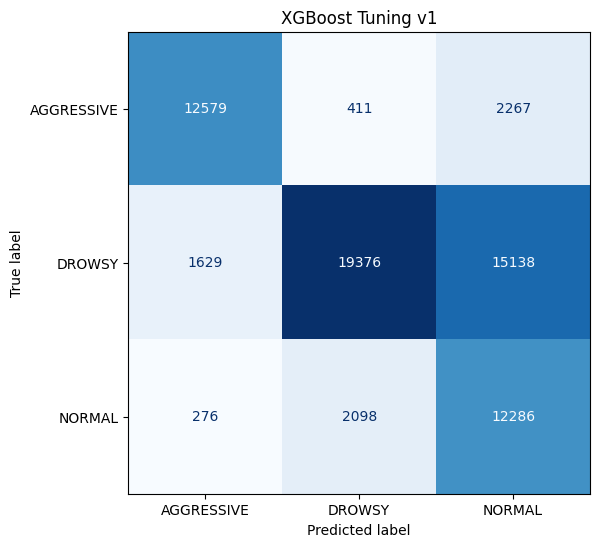

In [20]:
cm = confusion_matrix(
    y_test,
    xgb_pred_v1
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("XGBoost Tuning v1")

plt.show()

# XGBoost Tuning v2





In [21]:
xgb_model_v2 = XGBClassifier(

    random_state=42,

    objective="multi:softprob",
    num_class=3,

    n_estimators=500,

    learning_rate=0.03,

    max_depth=5,

    min_child_weight=3,

    gamma=0.1,

    subsample=0.9,

    colsample_bytree=0.9,

    reg_alpha=0.1,

    reg_lambda=2,

    eval_metric="mlogloss"

)

In [22]:
xgb_model_v2.fit(
    X_train,
    y_train
)

print("XGBoost Tuning v2 trained successfully!")

XGBoost Tuning v2 trained successfully!


In [23]:
xgb_pred_v2 = xgb_model_v2.predict(
    X_test
)

xgb_pred_v2[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [24]:
accuracy = accuracy_score(
    y_test,
    xgb_pred_v2
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6907


In [25]:
print(
    classification_report(
        y_test,
        xgb_pred_v2,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  AGGRESSIVE       0.87      0.83      0.85     15257
      DROWSY       0.92      0.55      0.69     36143
      NORMAL       0.44      0.89      0.59     14660

    accuracy                           0.69     66060
   macro avg       0.74      0.76      0.71     66060
weighted avg       0.80      0.69      0.70     66060



#XGBoost Tuning v3

In [26]:
xgb_model_v3 = XGBClassifier(

    random_state=42,

    objective="multi:softprob",
    num_class=3,

    n_estimators=800,
    learning_rate=0.02,

    max_depth=6,

    min_child_weight=1,

    gamma=0,

    subsample=0.85,
    colsample_bytree=0.85,

    reg_alpha=0,
    reg_lambda=1,

    eval_metric="mlogloss",

    tree_method="hist",
    n_jobs=-1
)

In [27]:
xgb_model_v3.fit(
    X_train,
    y_train
)

print("XGBoost Tuning v3 trained successfully!")

XGBoost Tuning v3 trained successfully!


In [28]:
xgb_pred_v3 = xgb_model_v3.predict(
    X_test
)

xgb_pred_v3[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [29]:
accuracy = accuracy_score(
    y_test,
    xgb_pred_v3
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6813


In [30]:
print(
    classification_report(
        y_test,
        xgb_pred_v3,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  AGGRESSIVE       0.88      0.83      0.85     15257
      DROWSY       0.90      0.55      0.68     36143
      NORMAL       0.42      0.86      0.57     14660

    accuracy                           0.68     66060
   macro avg       0.73      0.74      0.70     66060
weighted avg       0.79      0.68      0.70     66060



In [31]:
results = pd.DataFrame({

    "Model": [
        "XGBoost Baseline",
        "XGBoost Tuning v1",
        "XGBoost Tuning v2",
        "XGBoost Tuning v3"
    ],

    "Accuracy": [
        0.6800,
        0.6697,
        0.6907,
        0.6813
    ],

    "AGGRESSIVE Recall": [
        0.82,
        0.82,
        0.83,
        0.83
    ],

    "DROWSY Precision": [
        0.89,
        0.89,
        0.92,
        0.90
    ],

    "DROWSY Recall": [
        0.56,
        0.54,
        0.55,
        0.55
    ],

    "NORMAL Recall": [
        0.84,
        0.84,
        0.89,
        0.86
    ]

})

results

,Model,Accuracy,AGGRESSIVE Recall,DROWSY Precision,DROWSY Recall,NORMAL Recall
0,XGBoost Baseline,0.6800,0.82,0.89,0.56,0.84
1,XGBoost Tuning v1,0.6697,0.82,0.89,0.54,0.84
2,XGBoost Tuning v2,0.6907,0.83,0.92,0.55,0.89
3,XGBoost Tuning v3,0.6813,0.83,0.90,0.55,0.86


Observation

• Baseline model achieved the highest DROWSY recall (0.56).

• Tuning v2 achieved the highest overall accuracy (69.07%) and the highest DROWSY precision (0.92).

• Tuning v1 and v3 did not outperform the baseline consistently.

• Therefore, XGBoost Tuning v2 was selected as the final XGBoost model due to its superior overall classification performance.